## Smallest Circles -- Solution

Given a set of points in the plane $(x; y) \in \mathbb{R}^2$, we would like to find the circle with smallest possible
area that contains all of the points. Explain how to model this as an optimization problem. To test
your model, generate a set of 50 random points using the code X = randn(2,50) (this generates a
2$\times$50 matrix with row 1 being 50 x values and row 2 being 50 y values, so each column is an (x; y)
pair). 

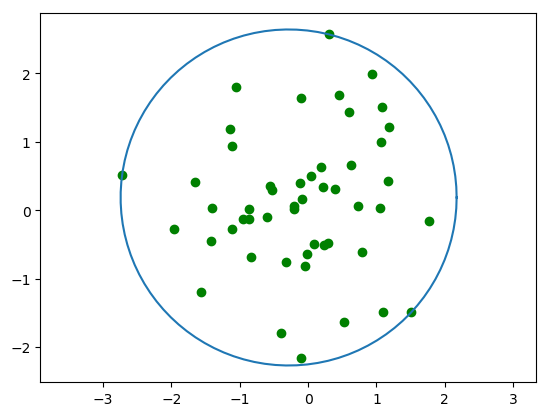

Academic license - for non-commercial use only


(-2.9997256172375386, 2.4183474408692165, -2.5157806803589375, 2.8890785931620133)

In [2]:
using PyPlot
seed = 345345
srand(seed)
X = randn(2,50) # generate 50 random points
t = linspace(0,2pi,100) # parameter that traverses the circle

using Gurobi, JuMP

n = size(X)[2]

m = Model(solver=GurobiSolver(OutputFlag=0))

@variable(m, d) # variable representing r^2
@variable(m, x) # x coordinate of circle center
@variable(m, y) # y coordinate of circle center

# find circle of minimum area
@objective(m, Min, pi*d)

# each point must lie no farther than the radium from the center
# (in 2-norm sense)
@constraint(m, constr[p in 1:n], (x - X[1,p])^2 + (y - X[2,p])^2 <= d)

solve(m)

plot( getvalue(x) + sqrt(getvalue(d))*cos.(t), getvalue(y) + sqrt(getvalue(d))*sin.(t)) # plot circle radius r with center (x1,x2)
scatter( X[1,:], X[2,:], color="green") # plot the 50 points
axis("equal") # make x and y scales equal

## Cryptocurrency Markets -- Solution

We have some money to invest and have decided to join the cryptocurrency craze. There are 6 different cryptocurrencies we can invest in. Each option has a minimum
and maximum investment allowed if that cryptocurrency is chosen. These restrictions, along with the
expected return are summarized in the following table (figures are in dollars):

|   Option | Minimum investment | Maximum investment | Expected return (%) |
|---------:|-------------------:|-------------------:|--------------------:|
|  Bitcoin (1) |                  4 |                 24 |                  20 |
| Ethereum (2)|                 18 |                 35 |                  15 |
| Dogecoin (3)|                  3 |                 13 |                  21 |
|      XRP (4)|                  6 |                 20 |                  19 |
|   Monero (5)|                 13 |                 19 |                  12 |
| Litecoin (6)|                  9 |                 18 |                  17 |

Because of the high-risk nature of Dogecoin (option 3),  the total amount invested in Dogecoin be no more that the combined amount invested in Bitcoin, Ethereum, and Litecoin. In addition, if
an investment is made in XRP, we require that at least the minimum investment be made in
Monero. We have $70 to invest and obviously we want to maximize our total expected return
on investment. Which options should we invest in, and how much should be invested in each?

In [3]:
using Gurobi, JuMP

options = [1:6]
min_invest = [4 18 3 6 13 9]
max_invest = [24 35 13 20 19 18]
roi = [20 15 21 19 12 17]

m = Model(solver=GurobiSolver(OutputFlag=0))

@variable(m, z[1:6], Bin)
@variable(m, x[1:6] >= 0)

@objective(m, Max, sum(roi[i]*x[i] for i in 1:6))

@constraint(m, min_inv[i in 1:6], x[i] >= min_invest[i]*z[i])
@constraint(m, max_inv[i in 1:6], x[i] <= max_invest[i]*z[i])
@constraint(m, x[3] <= x[1] + x[2] + x[6])
@constraint(m, sum(x) <= 70)
@constraint(m, x[4] <= z[5]*max_invest[4])

solve(m)

println(getobjectivevalue(m))
println(getvalue(z))
println(getvalue(x))

Academic license - for non-commercial use only
1289.0
[1.0, 0.0, 1.0, 1.0, 1.0, 0.0]
[24.0, 0.0, 13.0, 20.0, 13.0, 0.0]


We should invest in Bitcoin, Dogecoin, XRP, and Monero. We should invest \$24 in Bitcoin, \$13 in Dogecoin, \$20 in XRP, and \$13 in Monero for a total return of \$1289. We use all \$70.